# 📊 Data Loading and Normalization

## 🎯 Objective
In the following lines, we will:
- Load CSV data into the notebook
- Inspect the dataset
- Normalize selected numerical columns:
  - Temperature
  - Fuel_Price
  - CPI
  - Unemployment

In [4]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

##  Load Excel File

Since the dataset is in Excel format (.xlsx), we use `read_excel()` instead of `read_csv()`.

In [5]:
# Load the dataset
features_df = pd.read_excel("features.xlsx")
# Display first 5 rows
features_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


# Load CSV files

In [6]:
# Load the dataset
train_df = pd.read_csv("train.csv")
# Display first 5 rows
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [7]:
# Load the dataset
stores_df = pd.read_csv("stores.csv")
# Display first 5 rows
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [8]:
# Load the dataset
test_df = pd.read_csv("test.csv")
# Display first 5 rows
test_df.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


## 🔗 Merging Datasets for Feature Engineering

We will combine three datasets:

- `features_df`: contains economic and promotional data
- `stores_df`: contains store metadata (Type)
- `train_df`: contains sales data

### 🎯 Goal
Build a unified dataset for machine learning by merging on:
- Store
- Date
- IsHoliday

In [9]:
# Merge store type into features dataset
features_merged = features_df.merge(
    stores_df,
    on="Store",
    how="left"
)

features_merged.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


🟦 3. Merge train_df → features_merged

⚠️ IMPORTANT:
We merge on:

Store
Date
IsHoliday

## 🧩 Combining MarkDown Features

We combine `MarkDown1–5` into a single feature called `MarkDown`.

### Why?
- Reduces dimensionality
- Captures total promotional intensity
- Improves model stability



### Practical Assumption

We assume:
Negative MarkDown values do not represent real promotional effects and can be treated as noise.

---

### Common Handling Strategy

A simple and effective approach is to **clip negative values to zero**:

### NA Hnadling Strategy

Converting every NA into 0, since no markdowns before NOV 2011


In [26]:
from sklearn.preprocessing import MinMaxScaler

# MarkDown columns
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

# Step 1: Replace NA with 0
features_df[markdown_cols] = features_df[markdown_cols].fillna(0)

# Step 2: Clip negative values to 0
features_df[markdown_cols] = features_df[markdown_cols].clip(lower=0)

# Step 3: Create single MarkDown feature
features_df["MarkDown"] = features_df[markdown_cols].sum(axis=1)

# Optional: drop old columns (clean dataset)
features_df.drop(columns=markdown_cols, inplace=True)

# Step 4: Columns to normalize
columns_to_normalize = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown"
]

# Step 5: Normalize independently
scaler = MinMaxScaler()

for col in columns_to_normalize:
    features_df[col] = scaler.fit_transform(features_df[[col]])

features_df.head()

KeyError: "None of [Index(['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'], dtype='object')] are in the [columns]"

In [11]:

# Check your actual column names first, then use the correct ones:
train_df["Date"] = pd.to_datetime(train_df["Date"])
features_merged["Date"] = pd.to_datetime(features_merged["Date"])

# test_df might not have a Date column, or it might be named differently
# If test_df doesn't have a Date column, skip this line
if 'Date' in test_df.columns:
    test_df["Date"] = pd.to_datetime(test_df["Date"])
else:
    print("test_df doesn't have a 'Date' column. Available columns:", test_df.columns.tolist())

# Assuming your date column is named 'Date' 
date_col = 'Date'

# Get unique dates from available DataFrames
features_dates = set(features_df[date_col].unique())
train_dates = set(train_df[date_col].unique())

# Only check test_dates if test_df has the Date column
if 'Date' in test_df.columns:
    test_dates = set(test_df[date_col].unique())
    dates_in_test_not_train = test_dates - train_dates
    print(f"Total unique dates in test_df: {len(test_dates)}")
    print(f"Dates in test_df but NOT in train_df ({len(dates_in_test_not_train)}):")
    print(sorted(dates_in_test_not_train))

# Dates in features but not in train
dates_in_features_not_train = features_dates - train_dates

# Dates in train but not in features
dates_in_train_not_features = train_dates - features_dates

# Common dates
common_dates = features_dates.intersection(train_dates)

print(f"Total unique dates in features_df: {len(features_dates)}")
print(f"Total unique dates in train_df: {len(train_dates)}")
print(f"Common dates: {len(common_dates)}")
print(f"\nDates in features_df but NOT in train_df ({len(dates_in_features_not_train)}):")
print(sorted(dates_in_features_not_train))
print(f"\nDates in train_df but NOT in features_df ({len(dates_in_train_not_features)}):")
print(sorted(dates_in_train_not_features))

# Final merge: add all features to training data
full_df = train_df.merge(
    features_merged,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

full_df.head()

Total unique dates in test_df: 39
Dates in test_df but NOT in train_df (39):
[Timestamp('2012-11-02 00:00:00'), Timestamp('2012-11-09 00:00:00'), Timestamp('2012-11-16 00:00:00'), Timestamp('2012-11-23 00:00:00'), Timestamp('2012-11-30 00:00:00'), Timestamp('2012-12-07 00:00:00'), Timestamp('2012-12-14 00:00:00'), Timestamp('2012-12-21 00:00:00'), Timestamp('2012-12-28 00:00:00'), Timestamp('2013-01-04 00:00:00'), Timestamp('2013-01-11 00:00:00'), Timestamp('2013-01-18 00:00:00'), Timestamp('2013-01-25 00:00:00'), Timestamp('2013-02-01 00:00:00'), Timestamp('2013-02-08 00:00:00'), Timestamp('2013-02-15 00:00:00'), Timestamp('2013-02-22 00:00:00'), Timestamp('2013-03-01 00:00:00'), Timestamp('2013-03-08 00:00:00'), Timestamp('2013-03-15 00:00:00'), Timestamp('2013-03-22 00:00:00'), Timestamp('2013-03-29 00:00:00'), Timestamp('2013-04-05 00:00:00'), Timestamp('2013-04-12 00:00:00'), Timestamp('2013-04-19 00:00:00'), Timestamp('2013-04-26 00:00:00'), Timestamp('2013-05-03 00:00:00'), Time

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


# Normalization
We will normalize the following columns using Min-Max Scaling:
- Temperature
- Fuel_Price
- CPI
- Unemployment

This scales values between 0 and 1.

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Columns to normalize
columns_to_normalize = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

# Apply normalization column by column
for col in columns_to_normalize:
    scaler = MinMaxScaler()
    
    # reshape(-1,1) is REQUIRED for single column
    features_df[col] = scaler.fit_transform(features_df[[col]])

features_df.head()

,Store,Date,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,MarkDown
0,1,2010-02-05,0.454046,0.050100,0.826259,0.416032,False,0.0
1,1,2010-02-12,0.419260,0.038076,0.827676,0.416032,True,0.0
2,1,2010-02-19,0.432259,0.021042,0.828132,0.416032,False,0.0
3,1,2010-02-26,0.493592,0.044589,0.828429,0.416032,False,0.0
4,1,2010-03-05,0.492402,0.076653,0.828725,0.416032,False,0.0


In [13]:
features_df[columns_to_normalize].describe()

,Temperature,Fuel_Price,CPI,Unemployment
count,8190.000000,8190.000000,7605.000000,7605.000000
mean,0.610090,0.467932,0.450838,0.389766
std,0.170987,0.216100,0.386137,0.176617
min,0.000000,0.000000,0.000000,0.000000
25%,0.486932,0.285070,0.061225,0.277543
50%,0.622483,0.521543,0.550954,0.387807
75%,0.743043,0.636774,0.853817,0.459404
max,1.000000,1.000000,1.000000,1.000000


## 🔄 Encoding Boolean Feature: IsHoliday

The `IsHoliday` column contains boolean values:
- True → Holiday week
- False → Non-holiday week

### ⚙️ Transformation
To make it compatible with Machine Learning models, we convert:
- True → 1
- False → 0

In [14]:
# Convert boolean to binary (0/1)
features_df["IsHoliday"] = features_df["IsHoliday"].astype(int)

# Check result
features_df[["IsHoliday"]].head()

,IsHoliday
0,0
1,1
2,0
3,0
4,0


In [15]:
# Convert boolean to binary (0/1)
train_df["IsHoliday"] = train_df["IsHoliday"].astype(int)

# Check result
train_df[["IsHoliday"]].head()

,IsHoliday
0,0
1,1
2,0
3,0
4,0


In [16]:
features_df.head()

,Store,Date,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,MarkDown
0,1,2010-02-05,0.454046,0.050100,0.826259,0.416032,0,0.0
1,1,2010-02-12,0.419260,0.038076,0.827676,0.416032,1,0.0
2,1,2010-02-19,0.432259,0.021042,0.828132,0.416032,0,0.0
3,1,2010-02-26,0.493592,0.044589,0.828429,0.416032,0,0.0
4,1,2010-03-05,0.492402,0.076653,0.828725,0.416032,0,0.0


In [17]:
# Numerical columns to analyze
num_cols = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

## 🚨 Outlier Detection and Removal
first we will virtualize the outliers by Boxblot and Histogram
We use the Interquartile Range (IQR) method to detect extreme values.

### ⚠️ Important
We only remove statistical outliers from numeric features, while preserving meaningful business variations such as holidays and promotions.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

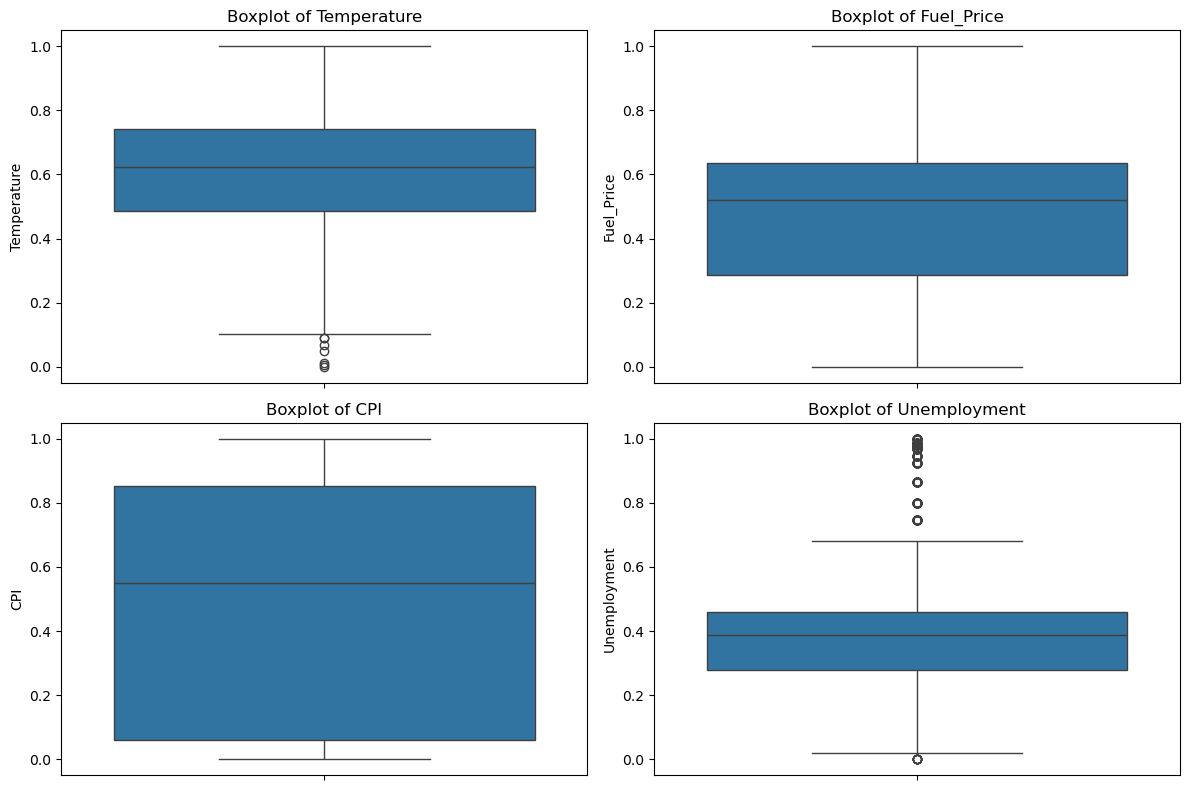

In [19]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=features_df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

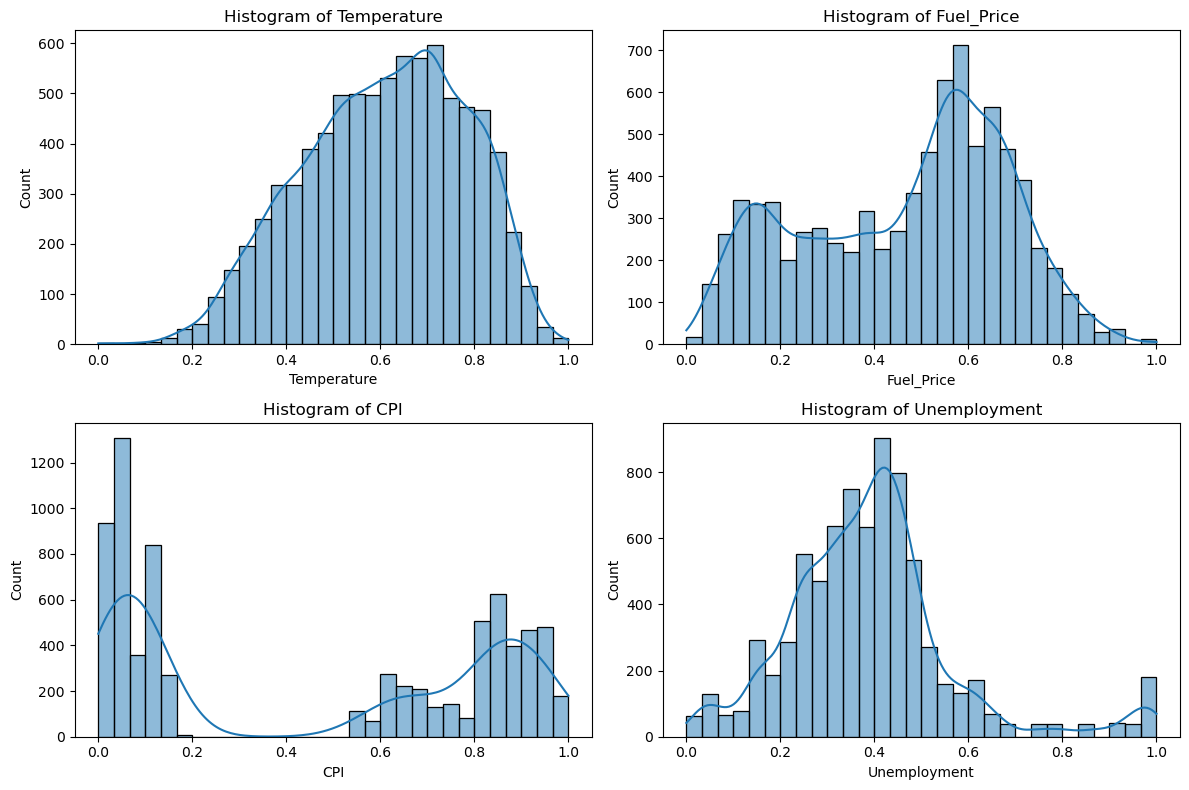

In [20]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(features_df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")

plt.tight_layout()
plt.show()

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct type
full_df["IsHoliday"] = full_df["IsHoliday"].astype(int)

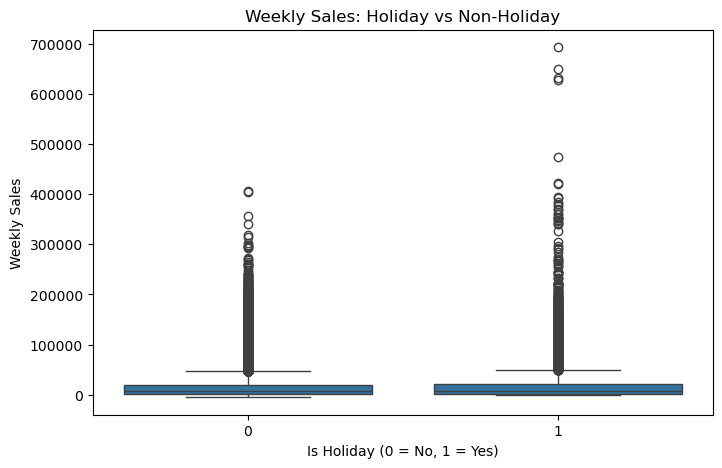

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="IsHoliday",
    y="Weekly_Sales",
    data=full_df
)

plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday (0 = No, 1 = Yes)")
plt.ylabel("Weekly Sales")

plt.show()

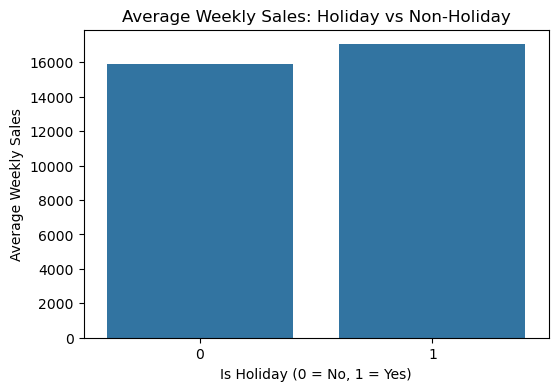

In [24]:
avg_sales = full_df.groupby("IsHoliday")["Weekly_Sales"].mean()

plt.figure(figsize=(6, 4))

sns.barplot(
    x=avg_sales.index,
    y=avg_sales.values
)

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday (0 = No, 1 = Yes)")
plt.ylabel("Average Weekly Sales")

plt.show()

## 📊 MarkDown vs Weekly Sales (Before vs After Nov 2011)

We split the analysis into two time periods:

- 📅 Before Nov 2011 → MarkDown data is not fully available
- 📅 After Nov 2011 → MarkDown data becomes active and meaningful

This helps us understand how promotions affect sales over time.

ValueError: Could not interpret value `MarkDown` for `x`. An entry with this name does not appear in `data`.

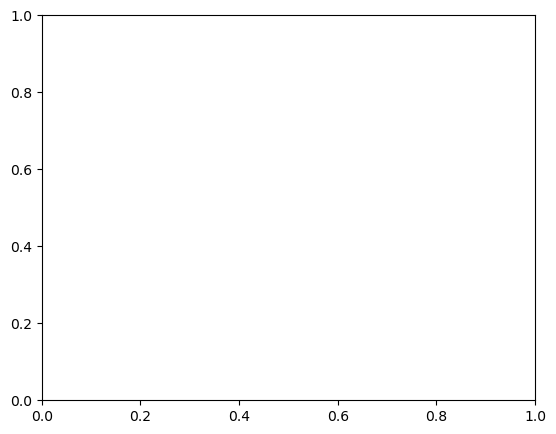

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure datetime format
full_df["Date"] = pd.to_datetime(full_df["Date"])

# Split based on Nov 2011
before_df = full_df[full_df["Date"] < "2011-11-01"]
after_df = full_df[full_df["Date"] >= "2011-11-01"]

plt.figure(figsize=(14, 5))

# --- Before Nov 2011 ---
plt.subplot(1, 2, 1)
sns.scatterplot(
    x="MarkDown",
    y="Weekly_Sales",
    data=before_df,
    alpha=0.4
)
plt.title("Before Nov 2011")
plt.xlabel("MarkDown")
plt.ylabel("Weekly Sales")

# --- After Nov 2011 ---
plt.subplot(1, 2, 2)
sns.scatterplot(
    x="MarkDown",
    y="Weekly_Sales",
    data=after_df,
    alpha=0.4
)
plt.title("After Nov 2011")
plt.xlabel("MarkDown")
plt.ylabel("Weekly Sales")

plt.tight_layout()
plt.show()

In [ ]:
max_markdown = full_df["MarkDown"].max()
print(f"Maximum MarkDown value: {max_markdown}")

Maximum MarkDown value: 0.8919707450266654


## 📊 MarkDown vs Weekly Sales (Holiday vs Non-Holiday)

We analyze the relationship between total promotional activity (`MarkDown`) and `Weekly_Sales`, separated by:

- 🎉 Holiday weeks
- 📅 Non-holiday weeks

This helps us understand whether promotions behave differently during holidays.

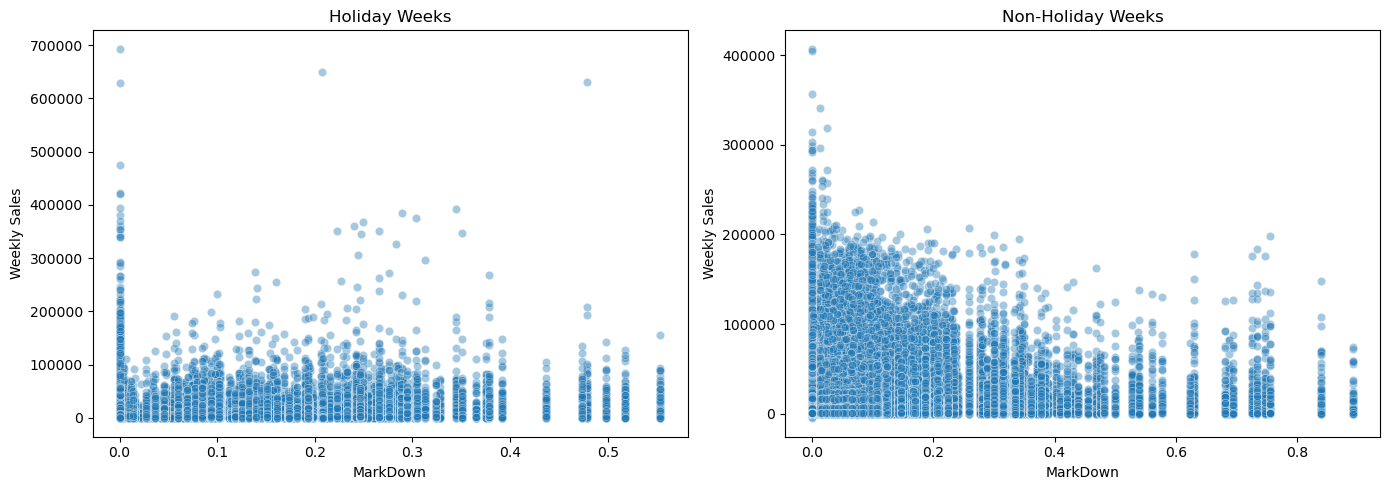

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure binary format
full_df["IsHoliday"] = full_df["IsHoliday"].astype(int)

# Split data
holiday_df = full_df[full_df["IsHoliday"] == 1]
non_holiday_df = full_df[full_df["IsHoliday"] == 0]

# Create figure
plt.figure(figsize=(14, 5))

# --- Holiday plot ---
plt.subplot(1, 2, 1)
sns.scatterplot(
    x="MarkDown",
    y="Weekly_Sales",
    data=holiday_df,
    alpha=0.4
)
plt.title("Holiday Weeks")
plt.xlabel("MarkDown")
plt.ylabel("Weekly Sales")

# --- Non-holiday plot ---
plt.subplot(1, 2, 2)
sns.scatterplot(
    x="MarkDown",
    y="Weekly_Sales",
    data=non_holiday_df,
    alpha=0.4
)
plt.title("Non-Holiday Weeks")
plt.xlabel("MarkDown")
plt.ylabel("Weekly Sales")

plt.tight_layout()
plt.show()

## 📊 Economic Features vs Weekly Sales (Holiday vs Non-Holiday)

We analyze how external economic factors affect `Weekly_Sales`, including:

- 🌡 Temperature
- ⛽ Fuel Price
- 📊 CPI (Consumer Price Index)
- 📉 Unemployment Rate

We split the analysis into:
- 🎉 Holiday weeks
- 📅 Non-holiday weeks

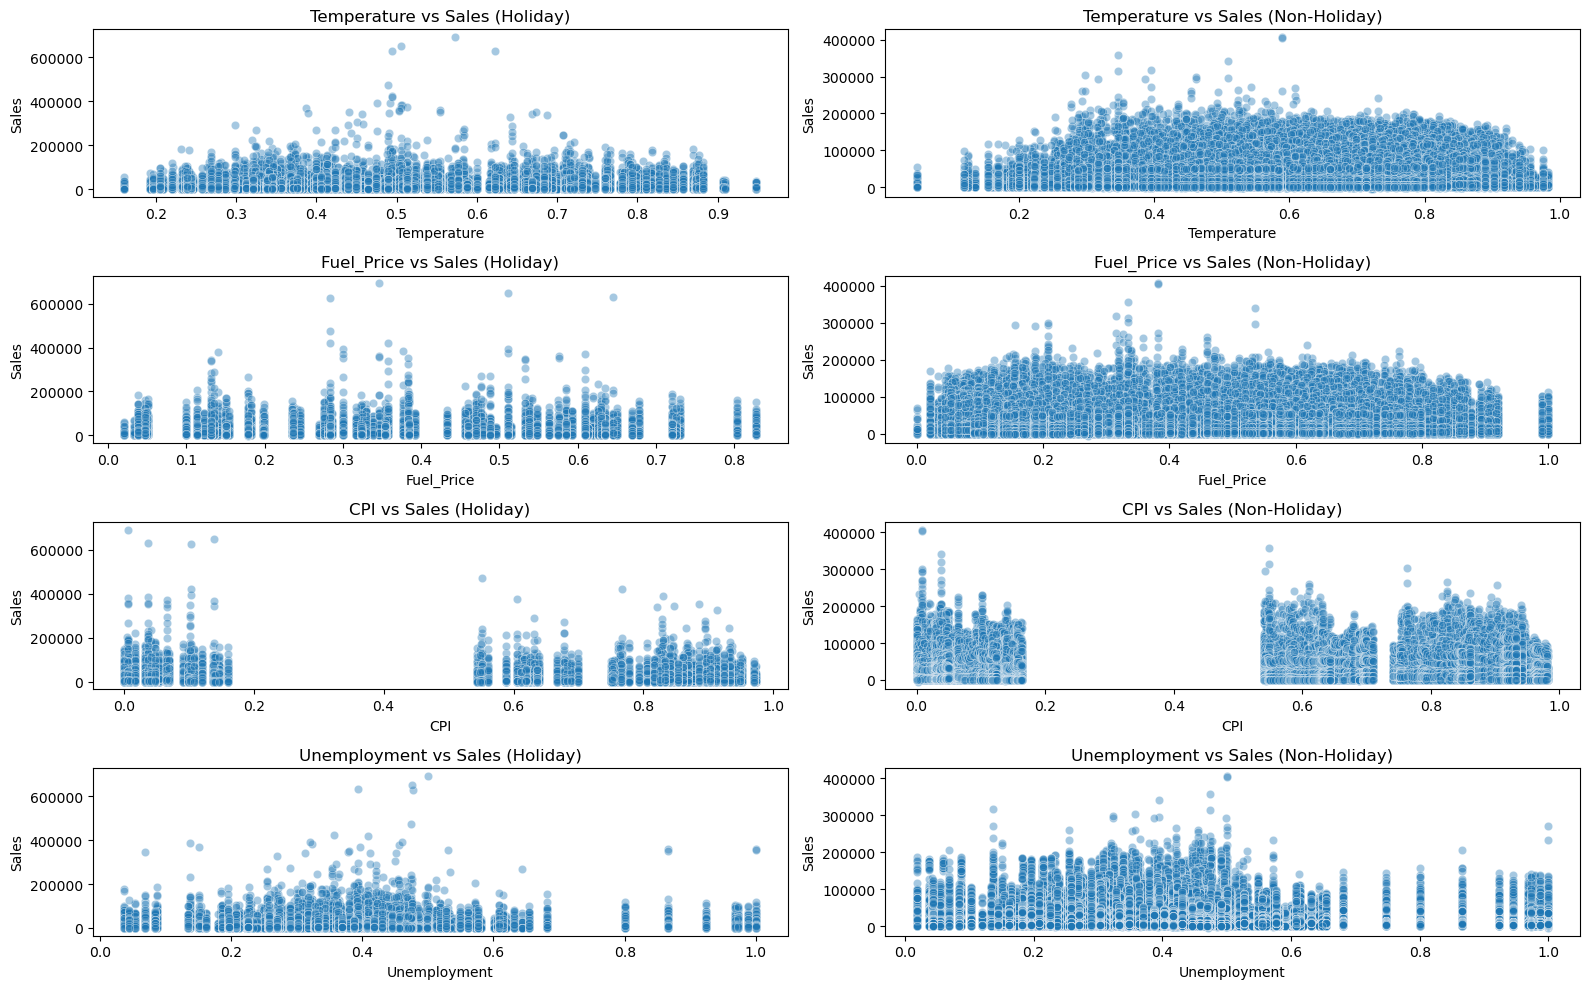

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct type
full_df["IsHoliday"] = full_df["IsHoliday"].astype(int)

features = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

holiday_df = full_df[full_df["IsHoliday"] == 1]
non_holiday_df = full_df[full_df["IsHoliday"] == 0]

plt.figure(figsize=(16, 10))

for i, feature in enumerate(features):
    
    # Holiday subplot
    plt.subplot(4, 2, i*2 + 1)
    sns.scatterplot(
        x=feature,
        y="Weekly_Sales",
        data=holiday_df,
        alpha=0.4
    )
    plt.title(f"{feature} vs Sales (Holiday)")
    plt.xlabel(feature)
    plt.ylabel("Sales")
    
    # Non-holiday subplot
    plt.subplot(4, 2, i*2 + 2)
    sns.scatterplot(
        x=feature,
        y="Weekly_Sales",
        data=non_holiday_df,
        alpha=0.4
    )
    plt.title(f"{feature} vs Sales (Non-Holiday)")
    plt.xlabel(feature)
    plt.ylabel("Sales")

plt.tight_layout()
plt.show()